# Acoustic Occupancy Modelling of Bats at Wind Farms

**Objective:** Implement the occupancy modelling framework from the literature review, progressing through increasingly complex models:

| Model | Reference | Handles FP? | Dynamic? | Spatial? | Count data? |
|---|---|---|---|---|---|
| 1. Single-season baseline | MacKenzie et al. 2002 [6] | No | No | No | No |
| 2. Single-season + covariates | MacKenzie et al. 2002 [6] | No | No | No | No |
| 3. Misclassification-aware | Miller et al. 2011 [9] | Yes | No | No | No |
| 4. Dynamic occupancy | MacKenzie et al. 2003 [8] | No | Yes | No | No |
| 5. Spatial occupancy | Johnson et al. 2013 [11] | No | No | Yes | No |
| 6. Count-based detection | Royle & Dorazio 2008 [7] | No | No | No | Yes |

**Data:** 7 sites (res-10 H3 hexes) surveyed by 8–13 detectors each; one survey = one detector × one noon-to-noon night (May – Oct 2024)  
**Validation:** Spatial block cross-validation following Roberts et al. 2017 [12] and Valavi et al. 2019 [13]  
**Covariates:** Effort (sample count), temporal (day of year, season), spatial (lat/lon, distance between sites)

## 1. Setup and Imports

In [1]:
import os, warnings

os.environ['PYTENSOR_FLAGS'] = 'device=cpu,floatX=float64,cxx='
os.environ['OMP_NUM_THREADS'] = '4'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import glob
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import pymc as pm
import arviz as az
from scipy import stats
from scipy.spatial.distance import pdist, squareform

# JAX/NumPyro backend for faster NUTS sampling
import pymc.sampling.jax as pmjax
import jax
print(f'JAX backend: {jax.default_backend()}')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

CORES = 2       # parallel chains (matches CPU count)
SEED = 42       # reproducibility
CV_DRAWS = 2000  # posterior draws per chain in each CV fold (fewer makes per-fold R-hat noisy)
CV_TUNE = 1000   # warm-up steps per chain in each CV fold

# --- Data config: which surveys go into the models ---
DATA_DIR = 'data/analytics/detector_nightly'  # ETL output: one row per night x hex x detector
MIN_SAMPLE_COUNT = 60        # surveys with fewer 1-min samples than this are dropped (deployment start/end stubs)
EXCLUDE_SERIALS = ['4095']   # detectors left out of every model; 4095 logged 21 nights with 0 files (suspected dead mic)

# --- Map export: model-vs-reality predictions (section 15) ---
PRED_DIR = 'data/analytics/occupancy_predictions'  # one Parquet per night, read by the API
PRED_INTERVAL = 0.9   # width of the predicted band written as pred_lo / pred_hi (0.9 = 5th to 95th percentile)
PRED_DRAWS = 2000     # posterior draws per fold used to simulate counts (at most CV_DRAWS x CORES)
HEX_SIGMA_PRIOR = 1.0 # HalfNormal scale for how much hexes differ on log(count); export model only

print(f'PyMC {pm.__version__}, ArviZ {az.__version__}')
print(f'NumPy {np.__version__}, Pandas {pd.__version__}')

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


JAX backend: cpu
PyMC 5.27.1, ArviZ 0.23.4
NumPy 2.5.3, Pandas 3.0.6


## 2. Load Data and Build Detection Histories

Occupancy models need **repeat surveys of the same site** to separate "absent" from "present but missed" (MacKenzie et al. 2002 [6]).

- **Site ($i$):** a resolution-10 H3 hex. All detectors in one deployment share a coordinate, so each hex = one wind farm × one deployment window (GANN ×2, MAUG ×3, MEEN ×2).
- **Survey ($k$):** one detector, one noon-to-noon night. Each site-night is surveyed by 8–13 detectors, which gives the replicate surveys the models need.
- **Detection ($y_k$):** 1 if the detector recorded any bat files that night.
- **Effort ($K_k$):** number of 1-minute samples the detector logged that night.

Data comes from `data/analytics/detector_nightly/`, written by the ETL (`transform/detector_nightly.py`). Surveys shorter than `MIN_SAMPLE_COUNT` and detectors in `EXCLUDE_SERIALS` are dropped (config in section 1).

**Limit on ψ:** all 7 sites have detections, so the data never shows an unoccupied site and ψ is only weakly identified — expect high, wide posteriors. Detection $p$ is now identifiable because detectors at the same site-night disagree.

In [2]:
# Load per-detector nightly surveys (one row per night x hex x detector)
parquet_files = sorted(glob.glob(f'{DATA_DIR}/detector_nightly_*.parquet'))
print(f'Found {len(parquet_files)} nightly parquet files')

surveys = pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)
n_raw = len(surveys)

is_stub = surveys['sample_count'] < MIN_SAMPLE_COUNT
is_excluded = surveys['detector_serial'].isin(EXCLUDE_SERIALS)
surveys = surveys[~is_stub & ~is_excluded].reset_index(drop=True)
print(f'Dropped {is_stub.sum()} stub surveys (< {MIN_SAMPLE_COUNT} samples) and '
      f'{(is_excluded & ~is_stub).sum()} surveys from excluded detectors {EXCLUDE_SERIALS}')

surveys['night'] = pd.to_datetime(surveys['night']).dt.date
surveys['site_id'] = surveys['h3_index']
surveys['y'] = (surveys['raw_count_sum'] > 0).astype(int)

print(f'\nModelling dataset: {len(surveys):,} of {n_raw:,} detector-night surveys')
print(f'Sites (H3 hexes): {surveys.site_id.nunique()}')
print(f'Detectors: {surveys.detector_serial.nunique()}')
print(f'Night range: {surveys.night.min()} to {surveys.night.max()}')
print(f'Total detections (raw_count_sum): {surveys.raw_count_sum.sum():,}')
print(f'Total samples: {surveys.sample_count.sum():,}')
print(f'Source folders: {surveys.source_folder.fillna("(top level)").value_counts().to_dict()}')

sites = sorted(surveys.site_id.unique())
dates = sorted(surveys.night.unique())
detectors = sorted(surveys.detector_serial.unique())
n_sites, n_dates, n_detectors = len(sites), len(dates), len(detectors)
site_to_idx = {s: i for i, s in enumerate(sites)}
date_to_idx = {d: i for i, d in enumerate(dates)}
det_to_idx = {d: i for i, d in enumerate(detectors)}

print(f'\n=> {n_sites} sites × {n_dates} nights, {n_detectors} detectors')

Found 122 nightly parquet files


Dropped 2 stub surveys (< 60 samples) and 21 surveys from excluded detectors ['4095']

Modelling dataset: 1,631 of 1,654 detector-night surveys
Sites (H3 hexes): 7
Detectors: 69
Night range: 2024-05-07 to 2024-10-08
Total detections (raw_count_sum): 138,577
Total samples: 998,590
Source folders: {'(top level)': 1419, 'special/D06': 146, 'special': 36, 'NA': 30}

=> 7 sites × 122 nights, 69 detectors


In [3]:
# Flat per-survey vectors: every model indexes its data by survey k
obs_site = surveys['site_id'].map(site_to_idx).to_numpy()
obs_date = surveys['night'].map(date_to_idx).to_numpy()
obs_det = surveys['detector_serial'].map(det_to_idx).to_numpy()
y_obs = surveys['y'].to_numpy()
n_obs_counts = surveys['raw_count_sum'].to_numpy()
effort_obs = surveys['sample_count'].to_numpy()
n_obs = len(y_obs)

# RULE: M1, M2, M5, M6 and the CV folds fix z_i = 1 (every site occupied), which is only valid while
# every site has at least one detection. If a filter or new data leaves a site with none, those models
# must marginalise z over {0, 1} the way M3 does, or they will silently overstate occupancy.
site_has_detection = np.bincount(obs_site, weights=y_obs, minlength=n_sites) > 0
assert site_has_detection.all(), f'sites with no detections: {np.array(sites)[~site_has_detection]}'

# Site x night summaries for the EDA plots (NaN = site not surveyed that night)
site_night = surveys.groupby(['site_id', 'night']).agg(
    frac=('y', 'mean'), effort=('sample_count', 'sum'), count=('raw_count_sum', 'sum'))
Y_frac = np.full((n_sites, n_dates), np.nan)   # share of detectors that detected
K_site = np.full((n_sites, n_dates), np.nan)   # total effort across detectors
N_site = np.full((n_sites, n_dates), np.nan)   # total raw counts across detectors
for (site, night), row in site_night.iterrows():
    i, t = site_to_idx[site], date_to_idx[night]
    Y_frac[i, t], K_site[i, t], N_site[i, t] = row['frac'], row['effort'], row['count']

print(f'Surveys: {n_obs:,}, with a detection: {y_obs.sum():,} (naive p = {y_obs.mean():.3f})')
print(f'Site-nights surveyed: {np.sum(~np.isnan(Y_frac)):.0f} / {n_sites * n_dates}')

per_site = surveys.groupby('site_id').agg(
    nights=('night', 'nunique'), detectors=('detector_serial', 'nunique'),
    surveys=('y', 'size'), naive_p=('y', 'mean'))
print('\nPer-site summary:')
print(per_site.round(3).to_string())

per_det = surveys.groupby('detector_serial')['y'].mean()
print(f'\nPer-detector naive p: min {per_det.min():.2f}, median {per_det.median():.2f}, max {per_det.max():.2f}')
print(f'Lowest five: {per_det.nsmallest(5).round(2).to_dict()}')

Surveys: 1,631, with a detection: 1,535 (naive p = 0.941)
Site-nights surveyed: 168 / 854

Per-site summary:
                 nights  detectors  surveys  naive_p
site_id                                             
8a1825695987fff      28         13      358    0.922
8a18256b266ffff      43         12      267    0.929
8a182a68218ffff      30         11      330    0.970
8a182a6828cffff      24         11      263    0.932
8a182a691a2ffff      14         12      166    0.988
8a182ecc2c8ffff      15          9      135    0.896
8a182ecc2d8ffff      14          8      112    0.955

Per-detector naive p: min 0.19, median 1.00, max 1.00
Lowest five: {'6979': 0.19, '7063': 0.38, '7093': 0.59, '7047': 0.75, '4023': 0.79}


## 3. Exploratory Data Analysis

Visualise detection patterns across sites and time to identify potential covariates for the occupancy and detection sub-models (Hayes 2000 [5]; Arnett et al. 2008 [1]; Baerwald & Barclay 2011 [2]).

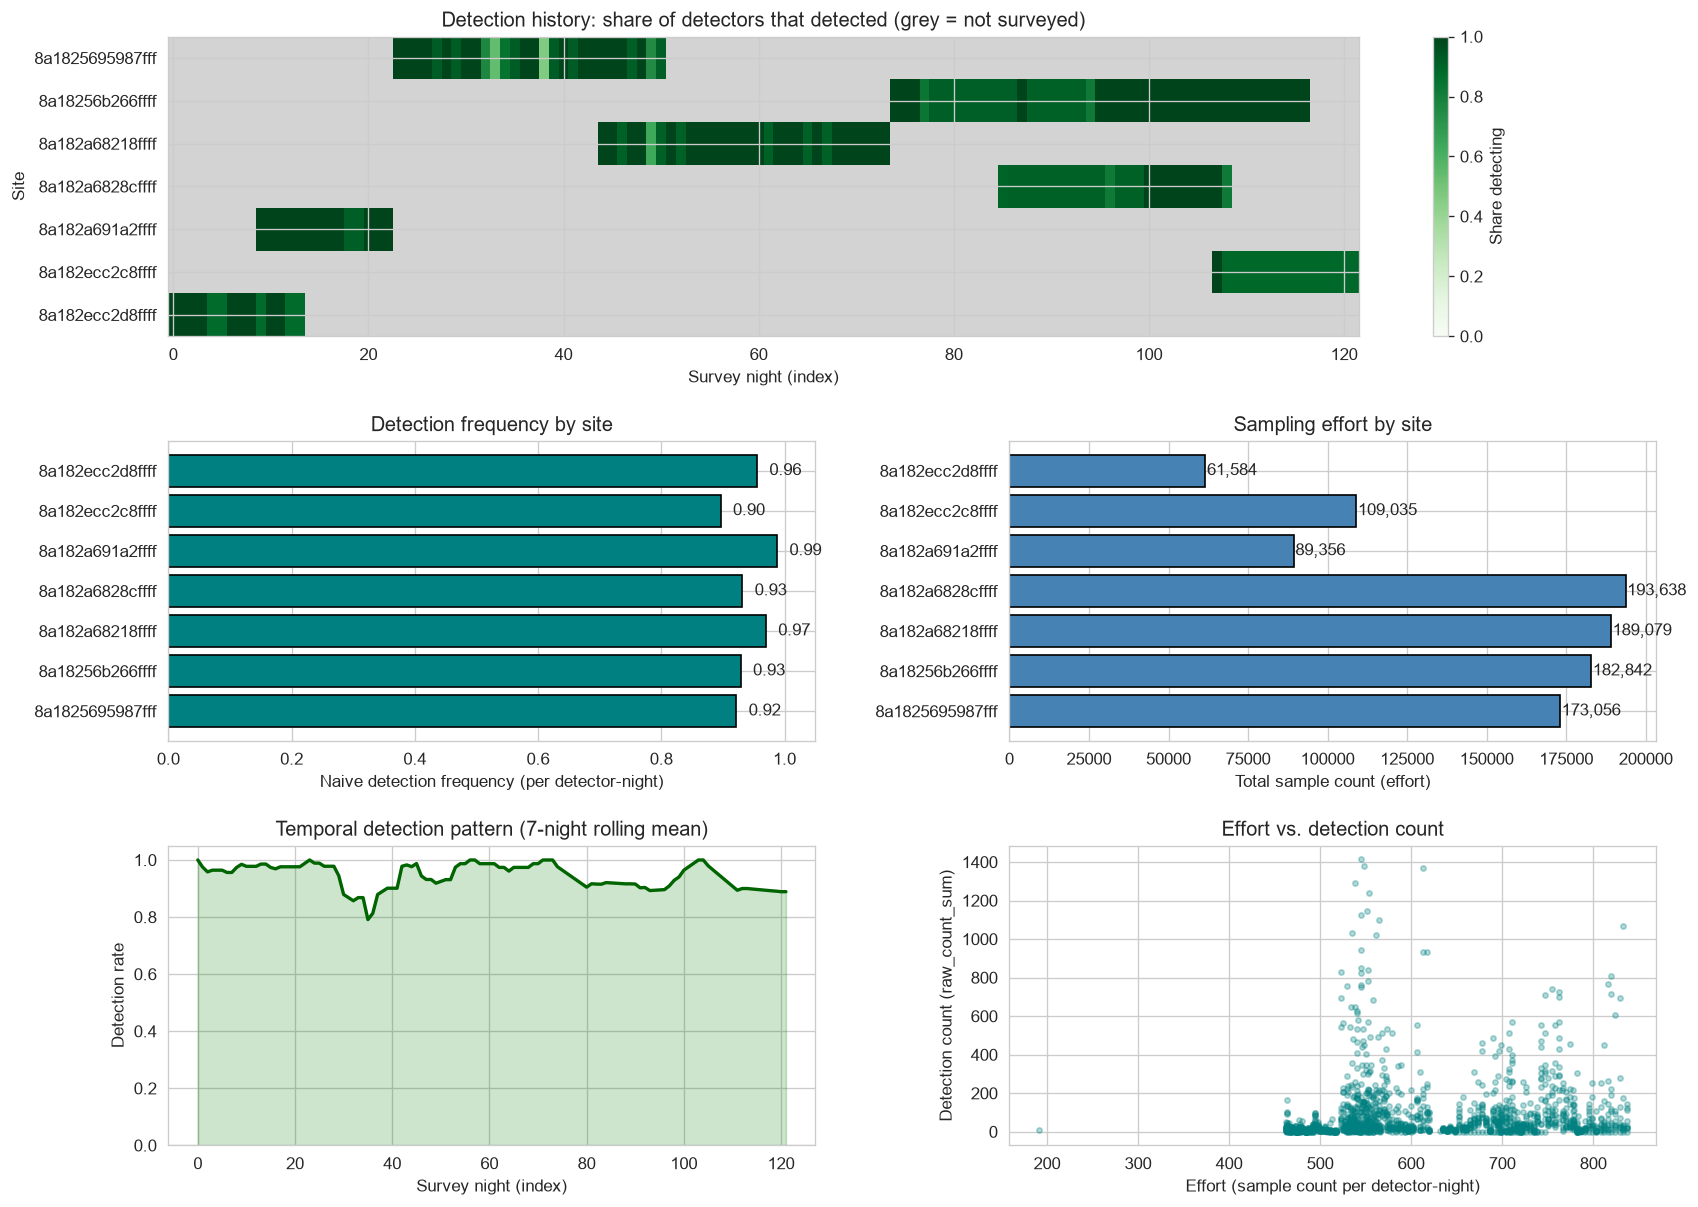

Saved: occupancy_eda.png


In [4]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# --- Plot 1: Detection history heatmap (share of detectors detecting each night) ---
ax1 = fig.add_subplot(gs[0, :])
cmap_frac = plt.cm.Greens.copy()
cmap_frac.set_bad('lightgrey')
im1 = ax1.imshow(np.ma.masked_invalid(Y_frac), aspect='auto', cmap=cmap_frac, vmin=0, vmax=1,
                 interpolation='nearest')
ax1.set_yticks(range(n_sites))
ax1.set_yticklabels(sites)
ax1.set_xlabel('Survey night (index)')
ax1.set_ylabel('Site')
ax1.set_title('Detection history: share of detectors that detected (grey = not surveyed)')
plt.colorbar(im1, ax=ax1, label='Share detecting')

# --- Plot 2: Detection frequency per site ---
ax2 = fig.add_subplot(gs[1, 0])
det_freq = per_site['naive_p'].reindex(sites).to_numpy()
ax2.barh(sites, det_freq, color='teal', edgecolor='black')
ax2.set_xlabel('Naive detection frequency (per detector-night)')
ax2.set_title('Detection frequency by site')
ax2.set_xlim(0, 1.05)
for i, v in enumerate(det_freq):
    ax2.text(v + 0.02, i, f'{v:.2f}', va='center')

# --- Plot 3: Effort per site ---
ax3 = fig.add_subplot(gs[1, 1])
effort_per_site = [np.nansum(K_site[i]) for i in range(n_sites)]
ax3.barh(sites, effort_per_site, color='steelblue', edgecolor='black')
ax3.set_xlabel('Total sample count (effort)')
ax3.set_title('Sampling effort by site')
for i, v in enumerate(effort_per_site):
    ax3.text(v + 500, i, f'{v:,.0f}', va='center')

# --- Plot 4: Temporal detection rate ---
ax4 = fig.add_subplot(gs[2, 0])
# Share of all surveys that detected, per night, smoothed
daily_det = surveys.groupby('night')['y'].mean().reindex(dates).to_numpy()
window = 7
smoothed = pd.Series(daily_det).rolling(window, min_periods=1, center=True).mean()
ax4.plot(range(n_dates), smoothed, color='darkgreen', linewidth=2)
ax4.fill_between(range(n_dates), smoothed, alpha=0.2, color='green')
ax4.set_xlabel('Survey night (index)')
ax4.set_ylabel('Detection rate')
ax4.set_title(f'Temporal detection pattern ({window}-night rolling mean)')
ax4.set_ylim(0, 1.05)

# --- Plot 5: Effort vs detection count, one point per survey ---
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(effort_obs, n_obs_counts, alpha=0.3, s=10, c='teal')
ax5.set_xlabel('Effort (sample count per detector-night)')
ax5.set_ylabel('Detection count (raw_count_sum)')
ax5.set_title('Effort vs. detection count')

plt.savefig('occupancy_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: occupancy_eda.png')

## 4. Prepare Covariates

Following the literature review's recommended covariate selection (Section 7, Table 2):

**Occupancy sub-model ($\psi$):**
- Spatial: site latitude/longitude (proxy for habitat/landscape; Yates 2010 [14], Ekman & de Jong 1996 [15])

**Detection sub-model ($p$):**
- Effort: log(sample_count) — detection opportunity varies with recorder uptime (Hayes 2000 [5])
- Temporal: day of year — bat activity peaks in late summer/autumn (Arnett et al. 2008 [1])
- Temporal: quadratic DOY term — captures seasonal unimodal peak (Baerwald & Barclay 2011 [2])

In [5]:
# --- Site-level covariates (occupancy sub-model) ---
# Extract lat/lon per site from H3 centroids
import h3

site_info = surveys.groupby('site_id').agg(
    total_raw=('raw_count_sum', 'sum'),
    total_samples=('sample_count', 'sum'),
    n_nights=('night', 'nunique'),
    n_detectors=('detector_serial', 'nunique'),
).reindex(sites).reset_index()

site_info['lat'] = site_info['site_id'].apply(lambda x: h3.cell_to_latlng(x)[0])
site_info['lon'] = site_info['site_id'].apply(lambda x: h3.cell_to_latlng(x)[1])

# Standardise spatial covariates
lat_raw = site_info['lat'].values
lon_raw = site_info['lon'].values
lat_std = (lat_raw - lat_raw.mean()) / lat_raw.std()
lon_std = (lon_raw - lon_raw.mean()) / lon_raw.std()

print('Site-level covariates:')
print(site_info[['site_id', 'lat', 'lon', 'n_nights', 'n_detectors', 'total_raw']].to_string(index=False))

# --- Observation-level covariates (detection sub-model), one value per survey ---
# Day of year for each night
doy = np.array([d.timetuple().tm_yday for d in dates])
doy_std = (doy - doy.mean()) / doy.std()  # standardised
doy_std2 = doy_std ** 2  # quadratic term
doy_obs = doy_std[obs_date]
doy2_obs = doy_std2[obs_date]

# Effort: log(sample_count) per survey, standardised
effort_log = np.log(effort_obs)
k_obs = (effort_log - effort_log.mean()) / effort_log.std()

print(f'\nTemporal covariates:')
print(f'  DOY range: {doy.min()} – {doy.max()} (standardised: {doy_std.min():.2f} – {doy_std.max():.2f})')
print(f'\nEffort covariate:')
print(f'  log(effort) mean: {effort_log.mean():.2f}, sd: {effort_log.std():.2f}')

print(f'\nModelling arrays: {n_obs} surveys from {n_sites} sites × {n_dates} nights, {n_detectors} detectors')
print(f'Detection rate in modelling data: {y_obs.mean():.3f}')

Site-level covariates:
        site_id       lat       lon  n_nights  n_detectors  total_raw
8a1825695987fff 54.719207 -7.899349        28           13       4678
8a18256b266ffff 54.738048 -7.921626        43           12      13576
8a182a68218ffff 51.751477 -9.298705        30           11      27356
8a182a6828cffff 51.752660 -9.288948        24           11      31570
8a182a691a2ffff 51.744767 -9.314892        14           12      24991
8a182ecc2c8ffff 53.315377 -8.580441        15            9      11676
8a182ecc2d8ffff 53.318236 -8.579061        14            8      24730

Temporal covariates:
  DOY range: 128 – 282 (standardised: -1.85 – 1.53)

Effort covariate:
  log(effort) mean: 6.40, sd: 0.18

Modelling arrays: 1631 surveys from 7 sites × 122 nights, 69 detectors
Detection rate in modelling data: 0.941


## 5. Model 1 — Single-Season Baseline (MacKenzie et al. 2002)

The foundational occupancy model from MacKenzie et al. [6]. **No covariates** — estimates global occupancy ($\psi$) and detection ($p$).

$$z_i \sim \text{Bernoulli}(\psi) \quad \text{(latent occupancy state)}$$
$$y_{i,t} \mid z_i \sim \text{Bernoulli}(z_i \cdot p) \quad \text{(observed detections)}$$

"Failing to account for imperfect detection leads to biased estimates of occupancy" — MacKenzie et al. 2002

In [6]:
# NOTE: All 7 sites have at least one detection, so z_i = 1 with certainty
# (no false positives in M1). We can marginalize z out analytically:
#   log P(data) = Σ_i log(ψ) + Σ_{i,t} [y log(p) + (1-y) log(1-p)]
# This eliminates discrete parameters → pure NUTS → fast sampling.

with pm.Model() as model_m1:
    psi = pm.Beta('psi', alpha=2, beta=2)
    p = pm.Beta('p', alpha=2, beta=2)
    
    # Occupancy contribution: all sites occupied → n_sites * log(ψ)
    pm.Potential('psi_ll', n_sites * pm.math.log(psi))
    
    # Detection: y_{i,t} ~ Bernoulli(p), given z_i = 1
    pm.Bernoulli('y_obs', p=p, observed=y_obs)
    
    # RULE: keep idata_kwargs log_likelihood on M1, M2, M5 and M6 - sample_numpyro_nuts omits it by
    # default, and section 12's az.compare / az.waic then fail with 'log likelihood not found'.
    trace_m1 = pmjax.sample_numpyro_nuts(2000, tune=1000, chains=CORES,
                                          random_seed=SEED, target_accept=0.9,
                                          idata_kwargs={'log_likelihood': True})

print('\n=== Model 1: Single-season baseline (z marginalized) ===')
print(az.summary(trace_m1, var_names=['psi', 'p'], round_to=3))

psi_post = trace_m1.posterior['psi'].values.flatten()
p_post = trace_m1.posterior['p'].values.flatten()
print(f'\nPosterior occupancy ψ: {psi_post.mean():.3f} [{np.percentile(psi_post, 2.5):.3f}, {np.percentile(psi_post, 97.5):.3f}]')
print(f'Posterior detection  p: {p_post.mean():.3f} [{np.percentile(p_post, 2.5):.3f}, {np.percentile(p_post, 97.5):.3f}]')

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/3000 [00:01<?, ?it/s]

...

Running chain 1: 100%|██████████| 3000/3000 [00:01<00:00, 2723.89it/s]


Running chain 0: 100%|██████████| 3000/3000 [00:01<00:00, 29010.67it/s]

Running chain 0: 100%|██████████| 3000/3000 [00:01<00:00, 2698.16it/s] 

We recommend running at least 4 chains for robust computation of convergence diagnostics



=== Model 1: Single-season baseline (z marginalized) ===
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
psi  0.816  0.113   0.610    0.990      0.002    0.002  2333.614  1267.697   
p    0.940  0.006   0.929    0.951      0.000    0.000  3429.798  2672.557   

     r_hat  
psi  1.001  
p    1.000  

Posterior occupancy ψ: 0.816 [0.543, 0.973]
Posterior detection  p: 0.940 [0.928, 0.951]


## 6. Model 2 — Single-Season with Covariates

Extend the baseline with covariates on both occupancy and detection, as recommended in the literature review Section 7:

$$\text{logit}(\psi_i) = \alpha_0 + \alpha_1 \cdot \text{lat}_i + \alpha_2 \cdot \text{lon}_i$$
$$\text{logit}(p_{i,t}) = \beta_0 + \beta_1 \cdot \text{effort}_{i,t} + \beta_2 \cdot \text{doy}_t + \beta_3 \cdot \text{doy}_t^2$$

Spatial covariates capture landscape influences on occupancy (Yates 2010 [14]; Ekman & de Jong 1996 [15]).  
Effort and temporal covariates model detection heterogeneity (Hayes 2000 [5]; Arnett et al. 2008 [1]).

In [7]:
# Marginalized over z (all sites have detections → z_i = 1 certain)

with pm.Model() as model_m2:
    # --- Occupancy sub-model ---
    alpha_0 = pm.Normal('alpha_0', mu=0, sigma=2)
    alpha_lat = pm.Normal('alpha_lat', mu=0, sigma=1)
    alpha_lon = pm.Normal('alpha_lon', mu=0, sigma=1)
    
    logit_psi = alpha_0 + alpha_lat * lat_std + alpha_lon * lon_std
    psi = pm.Deterministic('psi', pm.math.sigmoid(logit_psi))
    
    # Occupancy contribution: Σ_i log(ψ_i), since all z_i = 1
    pm.Potential('psi_ll', pm.math.sum(pm.math.log(psi)))
    
    # --- Detection sub-model ---
    beta_0 = pm.Normal('beta_0', mu=0, sigma=2)
    beta_effort = pm.Normal('beta_effort', mu=0, sigma=1)
    beta_doy = pm.Normal('beta_doy', mu=0, sigma=1)
    beta_doy2 = pm.Normal('beta_doy2', mu=0, sigma=1)
    
    # Detector random intercept: each detector's sensitivity offset, partially pooled
    sigma_det = pm.HalfNormal('sigma_det', sigma=1)
    # Non-centred (offset = raw * sigma) so NUTS avoids the funnel near sigma_det = 0: https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/multilevel_modeling.html
    det_offset_raw = pm.Normal('det_offset_raw', mu=0, sigma=1, shape=n_detectors)
    det_offset = pm.Deterministic('det_offset', det_offset_raw * sigma_det)
    
    logit_p = (beta_0 + beta_effort * k_obs + beta_doy * doy_obs + beta_doy2 * doy2_obs
               + det_offset[obs_det])
    p_det = pm.math.sigmoid(logit_p)
    
    # Detection likelihood: y ~ Bernoulli(p), given z = 1
    pm.Bernoulli('y_obs', p=p_det, observed=y_obs)
    
    trace_m2 = pmjax.sample_numpyro_nuts(2000, tune=1000, chains=CORES,
                                          random_seed=SEED, target_accept=0.9,
                                          idata_kwargs={'log_likelihood': True})

print('\n=== Model 2: Single-season + covariates (z marginalized) ===')
summary_m2 = az.summary(trace_m2, var_names=['alpha_0', 'alpha_lat', 'alpha_lon',
                                              'beta_0', 'beta_effort', 'beta_doy', 'beta_doy2', 'sigma_det'],
                         round_to=3)
print(summary_m2)
sd_m2 = trace_m2.posterior['sigma_det'].values.flatten()
print(f'\nDetector spread sigma_det (logit scale): {sd_m2.mean():.2f} '
      f'[{np.percentile(sd_m2, 2.5):.2f}, {np.percentile(sd_m2, 97.5):.2f}]  (0 = all detectors equally sensitive)')

print('\nCovariate interpretation (odds ratios for 1-SD change):')
for var in ['alpha_lat', 'alpha_lon', 'beta_effort', 'beta_doy', 'beta_doy2']:
    vals = trace_m2.posterior[var].values.flatten()
    or_val = np.exp(vals.mean())
    prob_pos = (vals > 0).mean()
    print(f'  {var}: OR = {or_val:.3f}, P(β > 0) = {prob_pos:.3f}')

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/3000 [00:01<?, ?it/s]

...

Running chain 0: 100%|██████████| 3000/3000 [00:05<00:00, 567.95it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:05<00:00, 843.25it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:05<00:00, 559.90it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics



=== Model 2: Single-season + covariates (z marginalized) ===
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_0      2.887  1.188   0.753    5.095      0.016    0.021  5765.131   
alpha_lat    0.004  0.844  -1.566    1.529      0.011    0.013  5689.699   
alpha_lon    0.011  0.871  -1.678    1.608      0.011    0.014  6230.847   
beta_0       3.839  0.470   2.955    4.709      0.012    0.008  1678.445   
beta_effort  0.348  0.395  -0.458    1.034      0.008    0.006  2358.290   
beta_doy    -0.785  0.418  -1.537    0.018      0.008    0.006  2618.638   
beta_doy2    0.568  0.362  -0.117    1.259      0.009    0.005  1793.987   
sigma_det    2.265  0.351   1.596    2.899      0.009    0.006  1371.949   

             ess_tail  r_hat  
alpha_0      2689.405  1.000  
alpha_lat    3433.271  1.000  
alpha_lon    3256.261  1.000  
beta_0       2449.348  1.001  
beta_effort  2415.888  1.001  
beta_doy     2519.921  1.000  
beta_doy2    2612.835  1.001  
sigma

## 7. Model 3 — Misclassification-Aware Occupancy (Miller et al. 2011)

"Automated acoustic classifiers can misidentify calls, particularly among species with similar echolocation characteristics" — Literature review Section 3.

Miller et al. [9] extend the detection process to distinguish:
- **True detection** (probability $p$)
- **False positive** (probability $fp$) — misidentification of non-bat sounds or other species
- **Non-detection** (probability $1 - p$)

$$y_{i,t} \mid z_i = 1 \sim \text{Bernoulli}(p)$$
$$y_{i,t} \mid z_i = 0 \sim \text{Bernoulli}(fp)$$

This means apparent detections can arise even at truly unoccupied sites.

In [8]:
# For the misclassification model, z CANNOT be determined from detections alone
# because false positives are possible (z=0 can produce y=1).
# We marginalize z properly using logsumexp per site.

with pm.Model() as model_m3:
    psi = pm.Beta('psi', alpha=2, beta=2)
    p_true = pm.Beta('p_true', alpha=2, beta=2)      # P(y=1 | z=1)
    p_fp = pm.Beta('p_fp', alpha=1, beta=9)           # P(y=1 | z=0), prior: low

    # Per-site marginalized log-likelihood
    for i in range(n_sites):
        mask_i = obs_site == i
        y_i = y_obs[mask_i]
        n_det = float(y_i.sum())
        n_nondet = float(len(y_i) - y_i.sum())
        
        # log P(data_i | z=1) = log(ψ) + Σ[y*log(p_true) + (1-y)*log(1-p_true)]
        ll_z1 = (pm.math.log(psi)
                 + n_det * pm.math.log(p_true)
                 + n_nondet * pm.math.log(1 - p_true))
        
        # log P(data_i | z=0) = log(1-ψ) + Σ[y*log(p_fp) + (1-y)*log(1-p_fp)]
        ll_z0 = (pm.math.log(1 - psi)
                 + n_det * pm.math.log(p_fp)
                 + n_nondet * pm.math.log(1 - p_fp))
        
        pm.Potential(f'll_{i}', pm.math.logsumexp(pm.math.stack([ll_z1, ll_z0])))

    trace_m3 = pmjax.sample_numpyro_nuts(2000, tune=1000, chains=CORES,
                                          random_seed=SEED, target_accept=0.95)

print('\n=== Model 3: Misclassification-aware (Miller et al. 2011), z marginalized ===')
print(az.summary(trace_m3, var_names=['psi', 'p_true', 'p_fp'], round_to=3))

psi3 = trace_m3.posterior['psi'].values.flatten()
p3 = trace_m3.posterior['p_true'].values.flatten()
fp3 = trace_m3.posterior['p_fp'].values.flatten()
print(f'\nOccupancy ψ: {psi3.mean():.3f} [{np.percentile(psi3, 2.5):.3f}, {np.percentile(psi3, 97.5):.3f}]')
print(f'True detection p: {p3.mean():.3f} [{np.percentile(p3, 2.5):.3f}, {np.percentile(p3, 97.5):.3f}]')
print(f'False positive fp: {fp3.mean():.3f} [{np.percentile(fp3, 2.5):.3f}, {np.percentile(fp3, 97.5):.3f}]')

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/3000 [00:01<?, ?it/s]

...

Running chain 1:  85%|████████▌ | 2550/3000 [00:01<00:00, 12034.95it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:01<00:00, 1514.65it/s] 


Running chain 0: 100%|██████████| 3000/3000 [00:01<00:00, 1506.62it/s] 


We recommend running at least 4 chains for robust computation of convergence diagnostics



=== Model 3: Misclassification-aware (Miller et al. 2011), z marginalized ===
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
psi     0.815  0.115   0.606    0.989      0.002    0.002  3395.860  1985.907   
p_true  0.940  0.006   0.930    0.951      0.000    0.000  3393.226  2478.740   
p_fp    0.100  0.091   0.000    0.268      0.001    0.002  2994.742  1886.711   

        r_hat  
psi     1.001  
p_true  1.001  
p_fp    1.000  

Occupancy ψ: 0.815 [0.549, 0.976]
True detection p: 0.940 [0.928, 0.951]
False positive fp: 0.100 [0.003, 0.342]


## 8. Model 4 — Dynamic Occupancy (MacKenzie et al. 2003)

"Dynamic occupancy models extend the framework to multiple primary periods, allowing explicit estimation of colonization ($\gamma$) and local extinction ($\varepsilon$)" — Literature review Section 2.2.

The latent state evolves as a Markov process:
$$z_{i,1} \sim \text{Bernoulli}(\psi_1)$$
$$z_{i,t} \mid z_{i,t-1} = 1 \sim \text{Bernoulli}(1 - \varepsilon)$$
$$z_{i,t} \mid z_{i,t-1} = 0 \sim \text{Bernoulli}(\gamma)$$

This captures how sites are colonised and abandoned across the season — critical for migratory bat species at wind farms (Arnett et al. 2008 [1]).

**Note:** With ~120 nightly primary periods this is computationally expensive. We aggregate into weekly periods, with every detector-night in the week as a replicate survey.

In [9]:
# Aggregate to weekly primary periods, with detector-night surveys as replicates
from datetime import date as dateclass

# Assign each night to a week index
date_objects = [dateclass.fromisoformat(str(d)) for d in dates]
base_date = date_objects[0]
week_idx = np.array([(d - base_date).days // 7 for d in date_objects])
n_weeks = int(week_idx.max()) + 1
obs_week = week_idx[obs_date]

# J_week[i, w] = detector-nights surveyed at site i in week w; det_count_week = those with a detection
J_week = np.zeros((n_sites, n_weeks))
det_count_week = np.zeros((n_sites, n_weeks))
# np.add.at adds once per survey even when (site, week) pairs repeat; fancy-index += would not
np.add.at(J_week, (obs_site, obs_week), 1)
np.add.at(det_count_week, (obs_site, obs_week), y_obs)

# Observed share of detector-nights with a detection (NaN = site not surveyed that week)
Y_week = np.full((n_sites, n_weeks), np.nan)
np.divide(det_count_week, J_week, out=Y_week, where=J_week > 0)

print(f'Weekly aggregation: {n_sites} sites × {n_weeks} weeks')
print(f'Valid site-weeks: {np.sum(J_week > 0):.0f} / {n_sites * n_weeks}')
print(f'Detector-nights per site-week: median {np.median(J_week[J_week > 0]):.0f}, max {J_week.max():.0f}')
print(f'Weekly share of detector-nights detecting: {np.nanmean(Y_week):.3f}')

Weekly aggregation: 7 sites × 23 weeks
Valid site-weeks: 29 / 161
Detector-nights per site-week: median 63, max 91
Weekly share of detector-nights detecting: 0.946


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [psi1, gamma, epsilon, p]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 101 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



=== Model 4: Dynamic occupancy (MacKenzie et al. 2003) ===
Binomial(J, p) likelihood within weekly primary periods
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
psi1     0.635  0.196   0.294    0.969      0.003    0.003  4153.361   
gamma    0.698  0.170   0.394    0.980      0.003    0.003  2959.632   
epsilon  0.056  0.045   0.001    0.134      0.001    0.001  3488.217   
p        0.940  0.006   0.929    0.951      0.000    0.000  4642.601   

         ess_tail  r_hat  
psi1     2528.741  1.000  
gamma    2263.147  1.000  
epsilon  2054.742  1.001  
p        2573.012  1.000  


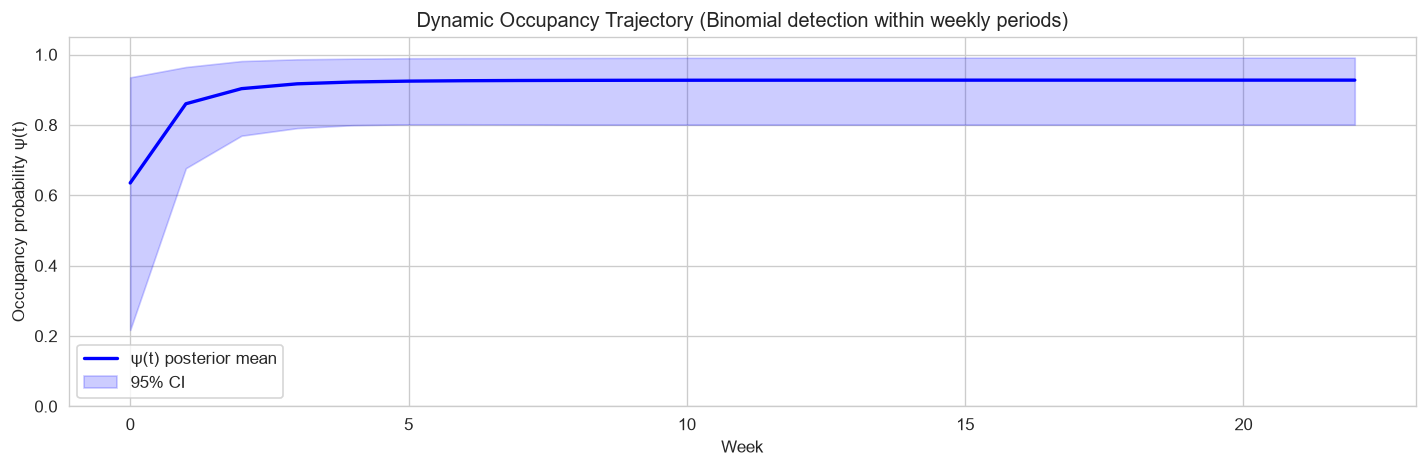

Saved: occupancy_dynamic_trajectory.png


In [10]:
# Build masked arrays for dynamic model
surveyed_week = J_week > 0

# Pre-compute observation indices for vectorised likelihood
obs_rows, obs_cols = np.where(surveyed_week)

# Use detection COUNTS per week and survey effort (MacKenzie et al. 2003, §3)
# Rather than collapsing to binary (any/none), the Binomial likelihood
# uses the number of detecting detector-nights out of J per primary period.
# This retains information: 60/70 detector-nights detected ≠ 10/70.
det_dyn = det_count_week[obs_rows, obs_cols]   # detector-nights with detections
j_dyn = J_week[obs_rows, obs_cols]             # total detector-nights surveyed

import pytensor
import pytensor.tensor as pt

with pm.Model() as model_m4:
    # Initial occupancy
    psi1 = pm.Beta('psi1', alpha=2, beta=2)
    
    # Transition probabilities
    gamma = pm.Beta('gamma', alpha=2, beta=2)    # colonisation
    epsilon = pm.Beta('epsilon', alpha=2, beta=2) # local extinction
    
    # Per-night detection probability within each primary period
    p = pm.Beta('p', alpha=2, beta=2)
    
    # Recursive occupancy: ψ(t) = ψ(t-1)(1-ε) + (1-ψ(t-1))γ
    # Use pytensor.scan for clean computation graph
    def step(psi_prev, gamma_, epsilon_):
        return psi_prev * (1 - epsilon_) + (1 - psi_prev) * gamma_
    
    psi_seq, _ = pytensor.scan(
        fn=step,
        outputs_info=psi1,
        non_sequences=[gamma, epsilon],
        n_steps=n_weeks - 1
    )
    # Full trajectory: psi1 + scanned values
    psi_all = pt.concatenate([pt.stack([psi1]), psi_seq])
    psi_trajectory = pm.Deterministic('psi_t', psi_all)
    
    psi_obs = psi_all[obs_cols]  # occupancy at each observation's week
    
    # --- Binomial likelihood marginalised over z ---
    from pytensor.tensor import gammaln
    
    log_choose = gammaln(j_dyn + 1) - gammaln(det_dyn + 1) - gammaln(j_dyn - det_dyn + 1)
    log_binom = log_choose + det_dyn * pt.log(p) + (j_dyn - det_dyn) * pt.log(1 - p)
    
    ll_detected = pt.log(psi_obs) + log_binom
    ll_zero = pt.logaddexp(
        pt.log(psi_obs) + j_dyn * pt.log(1 - p),   # occupied but missed all J nights
        pt.log(1 - psi_obs)                          # unoccupied
    )
    
    is_det = pt.gt(det_dyn, 0)
    ll_obs = pt.switch(is_det, ll_detected, ll_zero)
    
    pm.Potential('ll', pt.sum(ll_obs))
    
    # M4 uses pytensor.scan which JAX cannot JIT-compile; fall back to PyMC NUTS
    trace_m4 = pm.sample(2000, tune=1000, cores=CORES, random_seed=SEED,
                         target_accept=0.95, return_inferencedata=True)

print('\n=== Model 4: Dynamic occupancy (MacKenzie et al. 2003) ===')
print('Binomial(J, p) likelihood within weekly primary periods')
print(az.summary(trace_m4, var_names=['psi1', 'gamma', 'epsilon', 'p'], round_to=3))

# Extract occupancy trajectory
psi_traj = trace_m4.posterior['psi_t'].values
psi_traj_mean = psi_traj.mean(axis=(0, 1))
psi_traj_low = np.percentile(psi_traj, 2.5, axis=(0, 1))
psi_traj_high = np.percentile(psi_traj, 97.5, axis=(0, 1))

fig, ax = plt.subplots(figsize=(12, 4))
weeks_x = range(n_weeks)
ax.plot(weeks_x, psi_traj_mean, 'b-', linewidth=2, label='ψ(t) posterior mean')
ax.fill_between(weeks_x, psi_traj_low, psi_traj_high, alpha=0.2, color='blue', label='95% CI')
ax.set_xlabel('Week')
ax.set_ylabel('Occupancy probability ψ(t)')
ax.set_title('Dynamic Occupancy Trajectory (Binomial detection within weekly periods)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('occupancy_dynamic_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: occupancy_dynamic_trajectory.png')

## 9. Model 5 — Spatial Occupancy with Random Effects (Johnson et al. 2013)

"Johnson et al. present spatial occupancy models designed for large datasets, incorporating spatial random effects into the occurrence process" — Literature review Section 4.

We add site-level random intercepts with a spatial correlation structure based on exponential covariance:

$$\text{logit}(\psi_i) = \alpha_0 + \alpha_1 \cdot \text{lat}_i + \alpha_2 \cdot \text{lon}_i + \phi_i$$
$$\boldsymbol{\phi} \sim \text{MVN}(\mathbf{0}, \sigma^2_{\phi} \cdot \mathbf{C}(d))$$

Where $\mathbf{C}(d)$ is a spatial correlation matrix based on inter-site distances.

In [11]:
# Compute pairwise distance matrix between sites (km)
coords = np.column_stack([lat_raw, lon_raw])
# Approximate km using haversine-like scaling
lat_km = (coords[:, 0] - coords[:, 0].mean()) * 111.0
lon_km = (coords[:, 1] - coords[:, 1].mean()) * 111.0 * np.cos(np.radians(coords[:, 0].mean()))
coords_km = np.column_stack([lat_km, lon_km])
D = squareform(pdist(coords_km, metric='euclidean'))  # km distance matrix

print('Inter-site distances (km):')
dist_df = pd.DataFrame(D, index=sites, columns=sites).round(1)
print(dist_df)

import pytensor.tensor as pt

with pm.Model() as model_m5:
    # --- Occupancy sub-model with spatial random effects ---
    alpha_0 = pm.Normal('alpha_0', mu=0, sigma=2)
    alpha_lat = pm.Normal('alpha_lat', mu=0, sigma=1)
    alpha_lon = pm.Normal('alpha_lon', mu=0, sigma=1)
    
    # Spatial random effects
    sigma_phi = pm.HalfNormal('sigma_phi', sigma=1)   # spatial variance
    ell = pm.HalfNormal('ell', sigma=50)              # length scale (km)
    
    # Exponential correlation matrix
    R = pm.math.exp(-D / ell) + np.eye(n_sites) * 1e-6  # jitter for numerical stability
    L_R = pt.linalg.cholesky(R)
    
    # Non-centred phi = sigma_phi * L_R @ raw, the same MvNormal(0, sigma_phi^2 R) without the funnel a centred draw gives NUTS
    phi_raw = pm.Normal('phi_raw', mu=0, sigma=1, shape=n_sites)
    phi = pm.Deterministic('phi', sigma_phi * pt.dot(L_R, phi_raw))
    
    logit_psi = alpha_0 + alpha_lat * lat_std + alpha_lon * lon_std + phi
    psi = pm.Deterministic('psi', pm.math.sigmoid(logit_psi))
    
    # All sites have detections → z_i = 1 for all sites (known)
    # Add occupancy contribution as potential
    pm.Potential('psi_ll', pm.math.sum(pm.math.log(psi)))
    
    # --- Detection sub-model ---
    beta_0 = pm.Normal('beta_0', mu=0, sigma=2)
    beta_effort = pm.Normal('beta_effort', mu=0, sigma=1)
    beta_doy = pm.Normal('beta_doy', mu=0, sigma=1)
    beta_doy2 = pm.Normal('beta_doy2', mu=0, sigma=1)
    
    # Detector random intercept: each detector's sensitivity offset, partially pooled
    sigma_det = pm.HalfNormal('sigma_det', sigma=1)
    # Non-centred (offset = raw * sigma) so NUTS avoids the funnel near sigma_det = 0: https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/multilevel_modeling.html
    det_offset_raw = pm.Normal('det_offset_raw', mu=0, sigma=1, shape=n_detectors)
    det_offset = pm.Deterministic('det_offset', det_offset_raw * sigma_det)
    
    logit_p = (beta_0 + beta_effort * k_obs + beta_doy * doy_obs + beta_doy2 * doy2_obs
               + det_offset[obs_det])
    det_prob = pm.math.sigmoid(logit_p)
    
    y_like = pm.Bernoulli('y_obs', p=det_prob, observed=y_obs)
    
    trace_m5 = pmjax.sample_numpyro_nuts(2000, tune=1500, chains=CORES,
                                          random_seed=SEED, target_accept=0.95,
                                          idata_kwargs={'log_likelihood': True})

print('\n=== Model 5: Spatial occupancy (Johnson et al. 2013), z marginalized ===')
print(az.summary(trace_m5, var_names=['alpha_0', 'alpha_lat', 'alpha_lon',
                                       'sigma_phi', 'ell',
                                       'beta_0', 'beta_effort', 'beta_doy', 'beta_doy2', 'sigma_det'],
                  round_to=3))
sd_m5 = trace_m5.posterior['sigma_det'].values.flatten()
print(f'\nDetector spread sigma_det (logit scale): {sd_m5.mean():.2f} '
      f'[{np.percentile(sd_m5, 2.5):.2f}, {np.percentile(sd_m5, 97.5):.2f}]  (0 = all detectors equally sensitive)')

# Site-level occupancy estimates
psi5 = trace_m5.posterior['psi'].values
psi5_mean = psi5.mean(axis=(0, 1))
print('\nSite-level occupancy estimates (ψ):')
for i, site in enumerate(sites):
    vals = psi5[:, :, i].flatten()
    print(f'  {site}: {vals.mean():.3f} [{np.percentile(vals, 2.5):.3f}, {np.percentile(vals, 97.5):.3f}]')

Inter-site distances (km):
                 8a1825695987fff  8a18256b266ffff  8a182a68218ffff  \
8a1825695987fff              0.0              2.6            342.4   
8a18256b266ffff              2.6              0.0            344.0   
8a182a68218ffff            342.4            344.0              0.0   
8a182a6828cffff            342.1            343.7              0.7   
8a182a691a2ffff            343.4            345.0              1.3   
8a182ecc2c8ffff            162.3            163.9            180.1   
8a182ecc2d8ffff            162.0            163.6            180.4   

                 8a182a6828cffff  8a182a691a2ffff  8a182ecc2c8ffff  \
8a1825695987fff            342.1            343.4            162.3   
8a18256b266ffff            343.7            345.0            163.9   
8a182a68218ffff              0.7              1.3            180.1   
8a182a6828cffff              0.0              1.9            179.8   
8a182a691a2ffff              1.9              0.0            1

  0%|          | 0/3500 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3500 [00:00<?, ?it/s]

...

Running chain 0: 100%|██████████| 3500/3500 [00:07<00:00, 475.11it/s]

Running chain 1: 100%|██████████| 3500/3500 [00:07<00:00, 716.21it/s]

Running chain 1: 100%|██████████| 3500/3500 [00:07<00:00, 469.40it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics



=== Model 5: Spatial occupancy (Johnson et al. 2013), z marginalized ===
               mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_0       2.809   1.234   0.483    5.158      0.017    0.022  5448.563   
alpha_lat     0.001   0.856  -1.593    1.561      0.011    0.014  5573.483   
alpha_lon     0.030   0.865  -1.625    1.684      0.011    0.014  6004.905   
sigma_phi     0.768   0.604   0.000    1.855      0.009    0.010  2903.145   
ell          40.027  31.246   0.006   96.247      0.400    0.598  3325.391   
beta_0        3.860   0.482   3.038    4.843      0.013    0.008  1403.303   
beta_effort   0.356   0.412  -0.411    1.122      0.009    0.006  2091.311   
beta_doy     -0.793   0.433  -1.596    0.021      0.009    0.006  2305.959   
beta_doy2     0.551   0.356  -0.103    1.237      0.008    0.005  2019.456   
sigma_det     2.271   0.353   1.642    2.962      0.010    0.006  1250.329   

             ess_tail  r_hat  
alpha_0      2834.596  1.002  
alpha

## 10. Model 6 — Count-Based Detection (Royle & Dorazio 2008)

"Collapsing acoustic counts to binary detection/non-detection discards information about detection intensity" — Royle & Dorazio 2008 [7], Ch. 6.

Models M1–M5 binarise the raw acoustic counts ($n_{i,t}$) into detection/non-detection ($y_{i,t} \in \{0,1\}$). A count-based model retains the full information by modelling the counts directly via a **zero-inflated Negative Binomial**:

$$n_{i,t} \mid z_i = 1 \sim \text{NegBin}(\mu_{i,t}, \alpha) \quad \text{(occupied: counts follow NegBin)}$$
$$n_{i,t} \mid z_i = 0 = 0 \quad \text{(unoccupied: zero counts)}$$

With rate covariates on the count process:
$$\log(\mu_{i,t}) = \gamma_0 + \gamma_1 \cdot \text{effort}_{i,t} + \gamma_2 \cdot \text{doy}_t + \gamma_3 \cdot \text{doy}_t^2$$

The NegBin handles overdispersion common in acoustic count data (clustered call sequences, variable bat activity).

In [12]:
# Model 6: Count-based detection using raw acoustic counts
# Instead of binary y ∈ {0,1}, we model the actual counts n ∈ {0,1,2,...}
# This extracts more information from the data than binary occupancy models.

print(f'Count data summary:')
print(f'  Valid observations: {len(n_obs_counts)}')
print(f'  Zero counts: {(n_obs_counts == 0).sum()} ({(n_obs_counts == 0).mean():.1%})')
print(f'  Mean count (non-zero): {n_obs_counts[n_obs_counts > 0].mean():.1f}')
print(f'  Max count: {n_obs_counts.max()}')
print(f'  Variance/Mean ratio: {n_obs_counts.var() / max(n_obs_counts.mean(), 1e-6):.1f} (>1 → overdispersed)')

def build_m6(k, doy, doy2, counts, lat, lon, hex_idx=None):
    """M6 on the given surveys and sites; passing hex_idx (survey -> site) adds section 15's hex random effect."""
    with pm.Model() as model:
        # --- Occupancy sub-model (same structure as M2) ---
        alpha_0 = pm.Normal('alpha_0', mu=0, sigma=2)
        alpha_lat = pm.Normal('alpha_lat', mu=0, sigma=1)
        alpha_lon = pm.Normal('alpha_lon', mu=0, sigma=1)

        logit_psi = alpha_0 + alpha_lat * lat + alpha_lon * lon
        psi = pm.Deterministic('psi', pm.math.sigmoid(logit_psi))

        # All sites have detections → z_i = 1 (marginalize)
        pm.Potential('psi_ll', pm.math.sum(pm.math.log(psi)))

        # --- Count-based detection sub-model ---
        # log(μ) = γ_0 + γ_1·effort + γ_2·doy + γ_3·doy²
        gamma_0 = pm.Normal('gamma_0', mu=0, sigma=2)
        gamma_effort = pm.Normal('gamma_effort', mu=0, sigma=1)
        gamma_doy = pm.Normal('gamma_doy', mu=0, sigma=1)
        gamma_doy2 = pm.Normal('gamma_doy2', mu=0, sigma=1)

        log_mu = gamma_0 + gamma_effort * k + gamma_doy * doy + gamma_doy2 * doy2
        if hex_idx is not None:
            # Non-centred hex random intercept on log(μ), export variant only
            sigma_hex = pm.HalfNormal('sigma_hex', sigma=HEX_SIGMA_PRIOR)
            hex_raw = pm.Normal('hex_raw', mu=0, sigma=1, shape=len(lat))
            log_mu = log_mu + hex_raw[hex_idx] * sigma_hex
        mu = pm.math.exp(log_mu)

        # Overdispersion: NegBin(μ, α) — larger α → closer to Poisson
        alpha_nb = pm.HalfNormal('alpha_nb', sigma=5)

        # NegBin likelihood for counts (given z=1 for all sites)
        pm.NegativeBinomial('n_obs', mu=mu, alpha=alpha_nb, observed=counts)
    return model


model_m6 = build_m6(k_obs, doy_obs, doy2_obs, n_obs_counts, lat_std, lon_std)
with model_m6:
    trace_m6 = pmjax.sample_numpyro_nuts(2000, tune=1000, chains=CORES,
                                          random_seed=SEED, target_accept=0.9,
                                          idata_kwargs={'log_likelihood': True})

print('\n=== Model 6: Count-based detection (Royle & Dorazio 2008) ===')
summary_m6 = az.summary(trace_m6, var_names=['alpha_0', 'alpha_lat', 'alpha_lon',
                                              'gamma_0', 'gamma_effort', 'gamma_doy', 'gamma_doy2',
                                              'alpha_nb'],
                         round_to=3)
print(summary_m6)

print('\nCovariate interpretation (rate ratios for 1-SD change):')
for var in ['gamma_effort', 'gamma_doy', 'gamma_doy2']:
    vals = trace_m6.posterior[var].values.flatten()
    rr = np.exp(vals.mean())
    prob_pos = (vals > 0).mean()
    print(f'  {var}: RR = {rr:.3f}, P(γ > 0) = {prob_pos:.3f}')

alpha_vals = trace_m6.posterior['alpha_nb'].values.flatten()
print(f'\nOverdispersion α: {alpha_vals.mean():.2f} [{np.percentile(alpha_vals, 2.5):.2f}, {np.percentile(alpha_vals, 97.5):.2f}]')
print(f'  (larger α → closer to Poisson; small α → highly overdispersed)')

Count data summary:
  Valid observations: 1631
  Zero counts: 96 (5.9%)
  Mean count (non-zero): 90.3
  Max count: 1414
  Variance/Mean ratio: 303.8 (>1 → overdispersed)


  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

...

Running chain 1:  95%|█████████▌| 2850/3000 [00:08<00:00, 439.05it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:08<00:00, 439.39it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:08<00:00, 355.73it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics



=== Model 6: Count-based detection (Royle & Dorazio 2008) ===
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_0       2.887  1.196   0.770    5.187      0.022    0.026  3011.697   
alpha_lat    -0.013  0.850  -1.620    1.554      0.017    0.013  2591.555   
alpha_lon     0.011  0.860  -1.577    1.645      0.018    0.014  2382.414   
gamma_0       4.392  0.072   4.253    4.519      0.002    0.001  1451.696   
gamma_effort  1.442  0.125   1.208    1.672      0.003    0.002  1292.722   
gamma_doy    -1.265  0.127  -1.503   -1.028      0.003    0.002  1323.855   
gamma_doy2   -0.182  0.073  -0.314   -0.051      0.002    0.001  1244.527   
alpha_nb      0.572  0.018   0.539    0.607      0.000    0.000  2949.604   

              ess_tail  r_hat  
alpha_0       1623.959  1.000  
alpha_lat     2239.206  1.000  
alpha_lon     2438.747  1.000  
gamma_0       2150.409  1.001  
gamma_effort  1872.575  1.001  
gamma_doy     1871.629  1.001  
gamma_doy2    1935.

## 11. Spatial Block Cross-Validation (Roberts et al. 2017; Valavi et al. 2019)

"Standard random cross-validation can severely underestimate predictive error" for spatial data (Roberts et al. 2017 [12]).

We implement **leave-one-site-out** (spatial block) cross-validation, which is the natural spatial blocking strategy when sites are discrete detector locations (Valavi et al. 2019 [13]).

For each fold:
1. Hold out all observations from one site
2. Fit Model 2 (single-season + covariates) on remaining sites
3. Predict detection probability at the held-out site
4. Evaluate with log-likelihood and Brier score

In [13]:
print('=' * 60)
print('SPATIAL BLOCK CROSS-VALIDATION (leave-one-site-out)')
print('Roberts et al. 2017 [12]; Valavi et al. 2019 [13]')
print('=' * 60)

cv_results = []

for holdout in range(n_sites):
    # Split: train on all sites except holdout
    train_mask = obs_site != holdout
    test_mask = obs_site == holdout
    
    y_train = y_obs[train_mask]
    y_test = y_obs[test_mask]
    site_train = obs_site[train_mask]
    det_train = obs_det[train_mask]
    k_train = k_obs[train_mask]
    k_test = k_obs[test_mask]
    doy_train = doy_obs[train_mask]
    doy_test = doy_obs[test_mask]
    doy2_train = doy2_obs[train_mask]
    doy2_test = doy2_obs[test_mask]
    
    # Remap train site indices (remove holdout)
    train_sites = sorted(set(site_train))
    n_train_sites = len(train_sites)
    
    lat_train = np.array([lat_std[s] for s in train_sites])
    lon_train = np.array([lon_std[s] for s in train_sites])
    
    if len(y_test) == 0:
        continue
    
    # Marginalize z: all training sites have detections → z_i = 1 with certainty
    with pm.Model() as model_cv:
        a0 = pm.Normal('a0', mu=0, sigma=2)
        a_lat = pm.Normal('a_lat', mu=0, sigma=1)
        a_lon = pm.Normal('a_lon', mu=0, sigma=1)
        
        logit_psi_cv = a0 + a_lat * lat_train + a_lon * lon_train
        psi_cv = pm.math.sigmoid(logit_psi_cv)
        pm.Potential('psi_ll', pm.math.sum(pm.math.log(psi_cv)))
        
        b0 = pm.Normal('b0', mu=0, sigma=2)
        b_eff = pm.Normal('b_eff', mu=0, sigma=1)
        b_doy = pm.Normal('b_doy', mu=0, sigma=1)
        b_doy2 = pm.Normal('b_doy2', mu=0, sigma=1)
        s_det = pm.HalfNormal('s_det', sigma=1)
        det_raw_cv = pm.Normal('det_raw_cv', mu=0, sigma=1, shape=n_detectors)
        
        logit_p_cv = (b0 + b_eff * k_train + b_doy * doy_train + b_doy2 * doy2_train
                      + det_raw_cv[det_train] * s_det)
        p_cv = pm.math.sigmoid(logit_p_cv)
        pm.Bernoulli('y_cv', p=p_cv, observed=y_train)
        
        trace_cv = pmjax.sample_numpyro_nuts(CV_DRAWS, tune=CV_TUNE, chains=CORES,
                                              random_seed=SEED, target_accept=0.9)
    
    # Predict on holdout site
    b0_hat = trace_cv.posterior['b0'].mean().values
    b_eff_hat = trace_cv.posterior['b_eff'].mean().values
    b_doy_hat = trace_cv.posterior['b_doy'].mean().values
    b_doy2_hat = trace_cv.posterior['b_doy2'].mean().values
    a0_hat = trace_cv.posterior['a0'].mean().values
    a_lat_hat = trace_cv.posterior['a_lat'].mean().values
    a_lon_hat = trace_cv.posterior['a_lon'].mean().values
    
    # Predicted occupancy for holdout site
    psi_pred = 1 / (1 + np.exp(-(a0_hat + a_lat_hat * lat_std[holdout] + a_lon_hat * lon_std[holdout])))
    # Predicted detection at the average detector (offset 0): the held-out site is treated as unseen
    p_pred = 1 / (1 + np.exp(-(b0_hat + b_eff_hat * k_test + b_doy_hat * doy_test + b_doy2_hat * doy2_test)))
    
    # P(y=1) = psi * p (marginal over z)
    p_y1 = np.clip(psi_pred * p_pred, 1e-6, 1 - 1e-6)
    
    # Brier score and log-likelihood
    brier = np.mean((y_test - p_y1) ** 2)
    log_lik = np.sum(y_test * np.log(p_y1) + (1 - y_test) * np.log(1 - p_y1))
    
    cv_results.append({
        'holdout_site': sites[holdout],
        'n_test': len(y_test),
        'psi_pred': float(psi_pred),
        'brier': brier,
        'log_lik': log_lik
    })
    print(f'Fold {holdout+1}/{n_sites} (holdout={sites[holdout]}): '
          f'ψ_pred={psi_pred:.3f}, Brier={brier:.4f}, LL={log_lik:.1f}, n={len(y_test)}')

cv_df = pd.DataFrame(cv_results)
print(f'\n--- Summary ---')
print(f'Mean Brier score: {cv_df["brier"].mean():.4f} ± {cv_df["brier"].std():.4f}')
print(f'Mean log-likelihood: {cv_df["log_lik"].mean():.1f} ± {cv_df["log_lik"].std():.1f}')
print(f'\n{cv_df.to_string(index=False)}')

SPATIAL BLOCK CROSS-VALIDATION (leave-one-site-out)
Roberts et al. 2017 [12]; Valavi et al. 2019 [13]


  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

...

Running chain 0: 100%|██████████| 3000/3000 [00:05<00:00, 561.78it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:05<00:00, 838.25it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:05<00:00, 544.70it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


Fold 7/7 (holdout=8a182ecc2d8ffff): ψ_pred=0.942, Brier=0.0428, LL=-20.6, n=112

--- Summary ---
Mean Brier score: 0.0560 ± 0.0263
Mean log-likelihood: -53.9 ± 28.2

   holdout_site  n_test  psi_pred    brier    log_lik
8a1825695987fff     358  0.925760 0.072081 -98.194011
8a18256b266ffff     267  0.926548 0.066907 -69.834170
8a182a68218ffff     330  0.930697 0.034339 -56.912814
8a182a6828cffff     263  0.932932 0.064215 -66.434954
8a182a691a2ffff     166  0.931018 0.016465 -18.661131
8a182ecc2c8ffff     135  0.942225 0.094808 -46.813483
8a182ecc2d8ffff     112  0.941529 0.042847 -20.648466


## 12. Model Comparison and MCMC Diagnostics

Compare all fitted models using WAIC information criteria (Royle & Dorazio 2008 [7]) and verify convergence diagnostics.

MCMC DIAGNOSTICS
✓ M1: Baseline: max R̂ = 1.0012, min ESS = 2334
✓ M2: Covariates: max R̂ = 1.0010, min ESS = 1372
✓ M3: Misclass.: max R̂ = 1.0009, min ESS = 2995
✓ M4: Dynamic: max R̂ = 1.0006, min ESS = 2960
✓ M5: Spatial: max R̂ = 1.0023, min ESS = 1250
✓ M6: Counts: max R̂ = 1.0009, min ESS = 1293

MODEL COMPARISON — WAIC (Royle & Dorazio 2008 [7])



Binary detection models (same observed data):
                rank   elpd_waic     p_waic   elpd_diff        weight  \
M5: Spatial        0 -243.098030  32.301952    0.000000  1.000000e+00   
M2: Covariates     1 -243.693606  32.917864    0.595576  5.551115e-17   
M1: Baseline       2 -366.044386   0.975905  122.946355  1.200980e-17   

                       se        dse  warning scale  
M5: Spatial     21.715648   0.000000     True   log  
M2: Covariates  21.804061   0.213732     True   log  
M1: Baseline    26.232871  17.686226    False   log  

M6 (count-based) WAIC: -8361.4 ± 79.2
  (M6 uses NegBin likelihood on raw counts — not directly comparable to binary models)

Note: M3 (Potential-only) and M4 (Potential-only) lack observed likelihoods for WAIC.


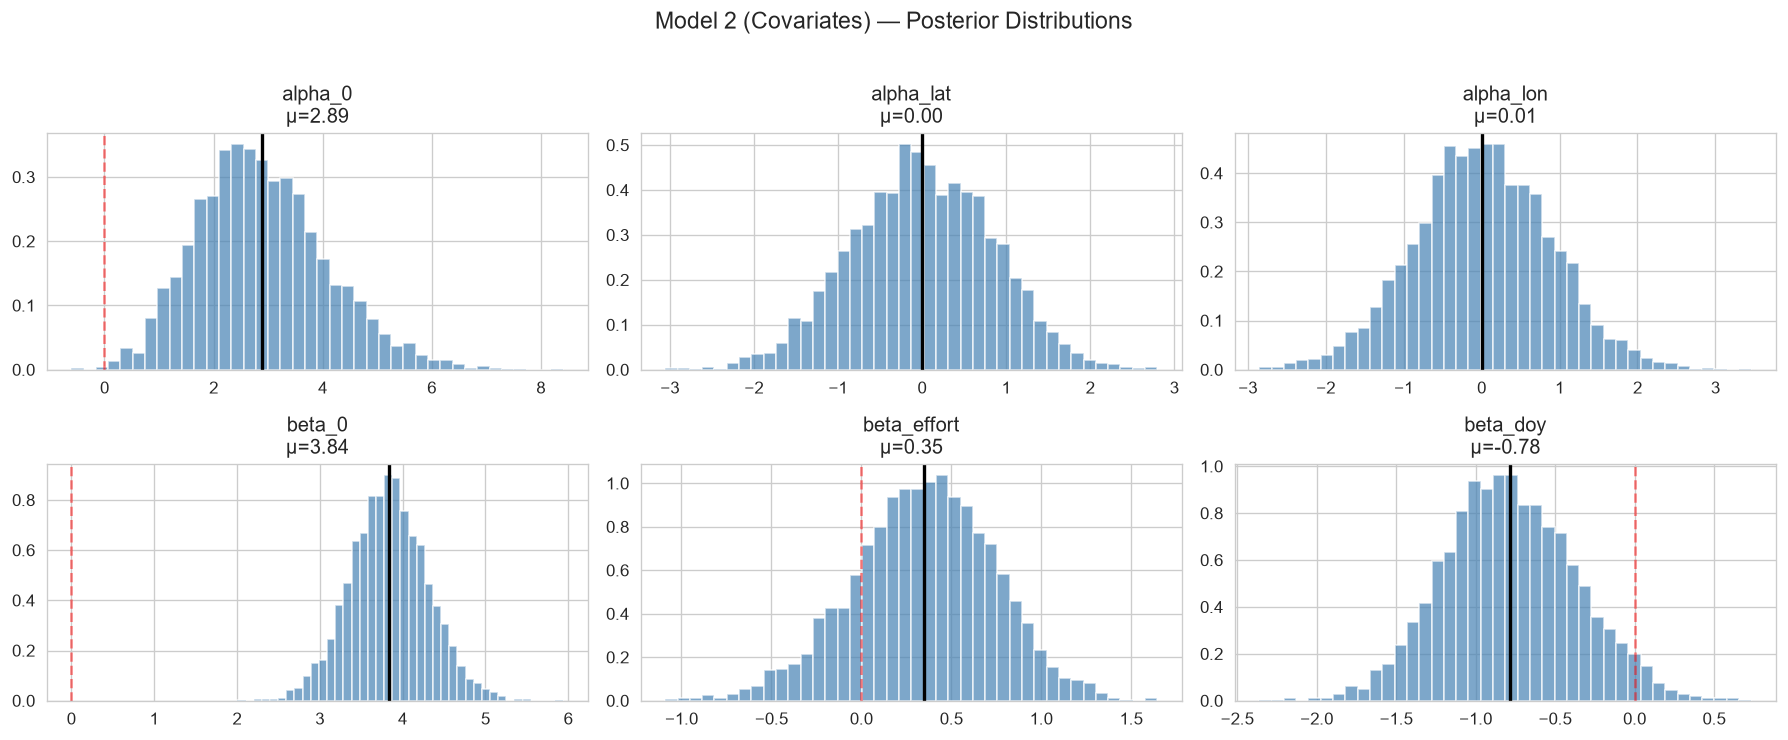

Saved: occupancy_posteriors.png


In [14]:
# ===== MCMC Diagnostics =====
print('=' * 60)
print('MCMC DIAGNOSTICS')
print('=' * 60)

models = {
    'M1: Baseline': trace_m1,
    'M2: Covariates': trace_m2,
    'M3: Misclass.': trace_m3,
    'M4: Dynamic': trace_m4,
    'M5: Spatial': trace_m5,
    'M6: Counts': trace_m6,
}

diag_vars = {
    'M1: Baseline': ['psi', 'p'],
    'M2: Covariates': ['alpha_0', 'beta_0', 'beta_effort', 'beta_doy', 'sigma_det'],
    'M3: Misclass.': ['psi', 'p_true', 'p_fp'],
    'M4: Dynamic': ['psi1', 'gamma', 'epsilon', 'p'],
    'M5: Spatial': ['alpha_0', 'sigma_phi', 'ell', 'beta_effort', 'sigma_det'],
    'M6: Counts': ['alpha_0', 'gamma_0', 'gamma_effort', 'alpha_nb'],
}

for name, trace in models.items():
    try:
        rhat = az.rhat(trace, var_names=diag_vars[name])
        max_rhat = max(float(rhat[v].max()) for v in diag_vars[name])
        ess = az.ess(trace, var_names=diag_vars[name])
        min_ess = min(float(ess[v].min()) for v in diag_vars[name])
        status = '✓' if max_rhat < 1.01 and min_ess > 400 else '⚠'
        print(f'{status} {name}: max R̂ = {max_rhat:.4f}, min ESS = {min_ess:.0f}')
    except Exception as e:
        print(f'⚠ {name}: diagnostics error — {e}')

# ===== Model Comparison (WAIC) =====
# WAIC requires observed likelihoods (pm.Bernoulli/NegBin), not pm.Potential.
# M3 and M4 use only pm.Potential → WAIC not available for those.
print('\n' + '=' * 60)
print('MODEL COMPARISON — WAIC (Royle & Dorazio 2008 [7])')
print('=' * 60)

# Binary detection models (M1, M2, M5 share the same y_obs Bernoulli likelihood)
try:
    compare_binary = az.compare(
        {'M1: Baseline': trace_m1, 'M2: Covariates': trace_m2, 'M5: Spatial': trace_m5},
        ic='waic'
    )
    print('\nBinary detection models (same observed data):')
    print(compare_binary)
except Exception as e:
    print(f'WAIC comparison (binary) failed: {e}')

# Count model (M6) uses different likelihood — report WAIC separately
try:
    waic_m6 = az.waic(trace_m6)
    print(f'\nM6 (count-based) WAIC: {waic_m6.elpd_waic:.1f} ± {waic_m6.se:.1f}')
    print('  (M6 uses NegBin likelihood on raw counts — not directly comparable to binary models)')
except Exception as e:
    print(f'M6 WAIC failed: {e}')

print('\nNote: M3 (Potential-only) and M4 (Potential-only) lack observed likelihoods for WAIC.')

# ===== Trace plots for key model =====
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

# Plot posteriors for M2 (most interpretable)
for i, var in enumerate(['alpha_0', 'alpha_lat', 'alpha_lon', 'beta_0', 'beta_effort', 'beta_doy']):
    vals = trace_m2.posterior[var].values.flatten()
    axes[i].hist(vals, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].axvline(vals.mean(), color='black', linewidth=2)
    axes[i].set_title(f'{var}\nμ={vals.mean():.2f}')

plt.suptitle('Model 2 (Covariates) — Posterior Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('occupancy_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: occupancy_posteriors.png')

## 13. Spatial Results Visualisation

Map site-level occupancy estimates and detection patterns across the study area.

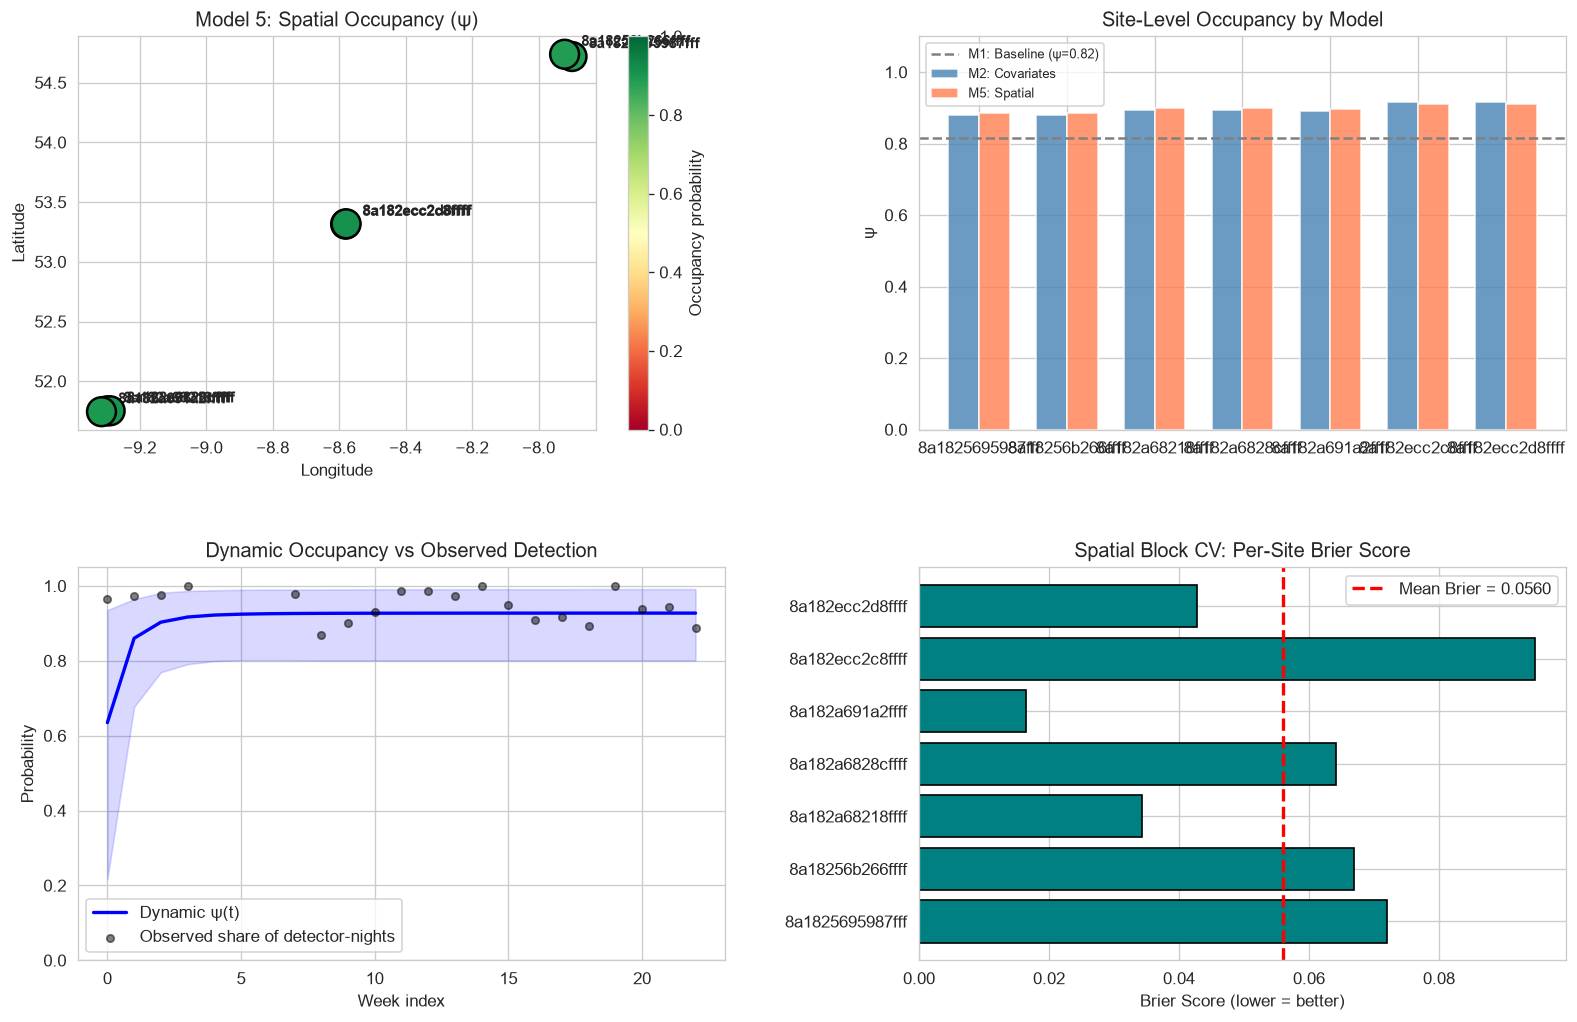

Saved: occupancy_results.png


In [15]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# --- Plot 1: Spatial occupancy map (Model 5) ---
ax1 = fig.add_subplot(gs[0, 0])
psi5_means = [trace_m5.posterior['psi'].values[:, :, i].flatten().mean() for i in range(n_sites)]
sc1 = ax1.scatter(lon_raw, lat_raw, c=psi5_means, s=300, cmap='RdYlGn',
                  vmin=0, vmax=1, edgecolor='black', linewidth=1.5, zorder=5)
for i, site in enumerate(sites):
    ax1.annotate(site, (lon_raw[i], lat_raw[i]), textcoords='offset points',
                 xytext=(10, 5), fontsize=9, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Model 5: Spatial Occupancy (ψ)')
plt.colorbar(sc1, ax=ax1, label='Occupancy probability')

# --- Plot 2: Model comparison - occupancy estimates ---
ax2 = fig.add_subplot(gs[0, 1])
# Collect occupancy estimates from different models
m1_psi = trace_m1.posterior['psi'].values.flatten().mean()
m3_psi = trace_m3.posterior['psi'].values.flatten().mean()
m2_psi_vals = [trace_m2.posterior['psi'].values[:, :, i].flatten().mean() for i in range(n_sites)]
m5_psi_vals = psi5_means

x_pos = np.arange(n_sites)
width = 0.35
ax2.bar(x_pos - width/2, m2_psi_vals, width, label='M2: Covariates', color='steelblue', alpha=0.8)
ax2.bar(x_pos + width/2, m5_psi_vals, width, label='M5: Spatial', color='coral', alpha=0.8)
ax2.axhline(m1_psi, color='grey', linestyle='--', label=f'M1: Baseline (ψ={m1_psi:.2f})')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(sites)
ax2.set_ylabel('ψ')
ax2.set_title('Site-Level Occupancy by Model')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 1.1)

# --- Plot 3: Temporal detection pattern with model fit ---
ax3 = fig.add_subplot(gs[1, 0])
# M4 dynamic trajectory
psi_traj_mean = trace_m4.posterior['psi_t'].values.mean(axis=(0, 1))
psi_traj_low = np.percentile(trace_m4.posterior['psi_t'].values, 2.5, axis=(0, 1))
psi_traj_high = np.percentile(trace_m4.posterior['psi_t'].values, 97.5, axis=(0, 1))
ax3.plot(range(n_weeks), psi_traj_mean, 'b-', linewidth=2, label='Dynamic ψ(t)')
ax3.fill_between(range(n_weeks), psi_traj_low, psi_traj_high, alpha=0.15, color='blue')
# Overlay observed weekly detection rate
obs_weekly_rate = np.nanmean(Y_week, axis=0)
ax3.scatter(range(n_weeks), obs_weekly_rate, s=20, c='black', alpha=0.5, label='Observed share of detector-nights', zorder=5)
ax3.set_xlabel('Week index')
ax3.set_ylabel('Probability')
ax3.set_title('Dynamic Occupancy vs Observed Detection')
ax3.legend()
ax3.set_ylim(0, 1.05)

# --- Plot 4: Cross-validation results ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.barh(cv_df['holdout_site'], cv_df['brier'], color='teal', edgecolor='black')
ax4.axvline(cv_df['brier'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean Brier = {cv_df["brier"].mean():.4f}')
ax4.set_xlabel('Brier Score (lower = better)')
ax4.set_title('Spatial Block CV: Per-Site Brier Score')
ax4.legend()

plt.savefig('occupancy_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: occupancy_results.png')

## 14. Summary

### Models Implemented

| # | Model | Framework | Key Parameters | Likelihood |
|---|---|---|---|---|
| M1 | Single-season baseline | MacKenzie et al. 2002 [6] | Global ψ, p | Binary |
| M2 | Single-season + covariates | MacKenzie et al. 2002 [6] | ψ(lat, lon), p(effort, DOY, DOY², detector) | Binary |
| M3 | Misclassification-aware | Miller et al. 2011 [9] | ψ, p_true, p_fp | Binary |
| M4 | Dynamic occupancy | MacKenzie et al. 2003 [8] | ψ₁, γ (colonization), ε (extinction), p | Binomial(J, p) |
| M5 | Spatial with random effects | Johnson et al. 2013 [11] | ψ(lat, lon, φ), p(effort, DOY, DOY², detector), spatial covariance | Binary |
| M6 | Count-based detection | Royle & Dorazio 2008 [7] | ψ(lat, lon), μ(effort, DOY, DOY²), α (overdispersion) | NegBin counts |

### Validation
- **Spatial block CV** (leave-one-site-out) following Roberts et al. 2017 [12] and Valavi et al. 2019 [13]
- **WAIC** information criterion for comparable models (M1, M2, M5 share binary Bernoulli likelihood)
- **MCMC diagnostics**: R̂, effective sample size for convergence assessment

### Key Findings (detector-nightly data: 1,631 surveys, 69 detectors, 7 sites)
- **Detection is now estimable:** p ≈ 0.94 [0.93, 0.95], because detectors at the same site-night disagree. On the old pooled hex-nights every value was 1, so p and ψ were ≈ 1 by construction.
- **Detectors differ a lot:** σ_det ≈ 2.3 on the logit scale (M2, M5). Per-detector naive p ranges 0.19–1.00. WAIC strongly prefers M2 over M1 (Δelpd ≈ 123 ± 18), so the detector effect is doing real work.
- **Occupancy ψ is still weakly identified:** all 7 sites have detections, so ψ ≈ 0.8–0.9 with wide intervals comes mostly from the prior. More sites (ideally some without bats) are needed to learn ψ.
- **Season:** detection falls later in the season (β_doy < 0 in M2; γ_doy < 0 in M6), and counts rise steeply with effort (M6 rate ratio ≈ 4 per SD of log effort).
- **Spatial term adds nothing yet:** M5 ≈ M2 in WAIC (Δelpd ≈ 0.6). With 7 sites in 3 tight clusters, σ_φ and the length scale are barely informed by the data.
- **Misclassification (M3):** false-positive rate is only loosely bounded (≈ 0.10 [0.00, 0.34]); with every site occupied the data barely inform it.
- Spatial block CV (leave-one-site-out) gives a mean Brier score of ≈ 0.056.

### References
All model implementations follow the framework laid out in the literature review:
- [1] Arnett et al. 2008 — Bat fatality patterns at wind facilities
- [2] Baerwald & Barclay 2011 — Activity and fatality at Alberta wind facility
- [5] Hayes 2000 — Echolocation monitoring design considerations
- [6] MacKenzie et al. 2002 — Single-season occupancy
- [7] Royle & Dorazio 2008 — Hierarchical modelling perspective (count-based detection)
- [8] MacKenzie et al. 2003 — Dynamic occupancy
- [9] Miller et al. 2011 — False-positive occupancy models
- [11] Johnson et al. 2013 — Spatial occupancy for large datasets
- [12] Roberts et al. 2017 — Cross-validation for structured data
- [13] Valavi et al. 2019 — blockCV for spatial validation
- [14] Yates 2010 — Forest structure and bat occupancy
- [15] Ekman & de Jong 1996 — Patch isolation and bat distribution

## 15. Export: Model vs Reality for the Map

The map's *Model vs reality* mode compares the bat activity each hex actually recorded on a night with what M6 expected there.

**Out-of-sample:** each hex is predicted by a fit that never saw that hex (leave-one-hex-out, the same folds as section 11). Otherwise the model would partly be "predicting" data it was trained on.

**Hex random effect (export only):** the fit is M6 plus a per-hex intercept on log(μ) with spread σ_hex (`build_m6(..., hex_idx=...)`). The held-out hex has no fitted intercept, so each draw gives it a fresh one from Normal(0, σ_hex): the band then includes "this might be a busier or quieter site than average". Section 10's M6 stays the plain baseline.

**Posterior predictive:** for each posterior draw, simulate a count for every detector-night at the held-out hex from NegBin(μ, α), then sum the detectors surveyed that night. Repeating this over `PRED_DRAWS` draws gives a distribution for the hex-night total: `pred_mean` is its mean, `pred_median` its median (the typical site, used for the map colour), `pred_lo`/`pred_hi` the central `PRED_INTERVAL` band. Every hex is assumed occupied (z = 1), as in M6's fit.

**Reading it:** `pred_mean` is the activity expected at a typical site given effort and season, so the colour says whether a hex is busier or quieter than typical; the band says whether that is surprising given how much sites vary.

One Parquet per night in `PRED_DIR`: `night | h3_index | observed | pred_mean | pred_median | pred_lo | pred_hi | n_detectors | prediction_kind`.

In [16]:
print('=' * 60)
print('MODEL VS REALITY EXPORT (leave-one-hex-out M6 + hex random effect)')
print('=' * 60)

rng = np.random.default_rng(SEED)
tail = (1 - PRED_INTERVAL) / 2
pred_rows = []

for holdout in range(n_sites):
    train, test = obs_site != holdout, obs_site == holdout
    train_sites = np.unique(obs_site[train])
    train_hex = np.searchsorted(train_sites, obs_site[train])  # site index -> 0..n_train_sites-1

    with build_m6(k_obs[train], doy_obs[train], doy2_obs[train], n_obs_counts[train],
                  lat_std[train_sites], lon_std[train_sites], hex_idx=train_hex):
        trace_fold = pmjax.sample_numpyro_nuts(CV_DRAWS, tune=CV_TUNE, chains=CORES,
                                               random_seed=SEED, target_accept=0.9)

    post = trace_fold.posterior.stack(sample=('chain', 'draw'))
    pick = rng.choice(post.sizes['sample'], PRED_DRAWS, replace=False)
    draw = {v: post[v].values[pick][:, None] for v in ['gamma_0', 'gamma_effort', 'gamma_doy', 'gamma_doy2', 'alpha_nb', 'sigma_hex']}

    # RULE: draw the unseen hex's intercept ONCE per posterior draw (shape draws x 1) and share it across all its
    # detectors and nights. Drawing it per survey looks the same but averages out in the nightly sum, and the band
    # shrinks back to the no-hex-effect width.
    new_hex = rng.normal(size=(PRED_DRAWS, 1)) * draw['sigma_hex']
    # (draws x test surveys) expected counts at the held-out hex
    mu = np.exp(draw['gamma_0'] + draw['gamma_effort'] * k_obs[test]
                + draw['gamma_doy'] * doy_obs[test] + draw['gamma_doy2'] * doy2_obs[test] + new_hex)
    # NegBin(mu, alpha) sampled as its Gamma-Poisson mixture: rate ~ Gamma(alpha, mu/alpha), count ~ Poisson(rate)
    sim = rng.poisson(rng.gamma(draw['alpha_nb'], mu / draw['alpha_nb']))

    # RULE: sum the detectors WITHIN each draw, then take quantiles of those totals. Summing per-detector
    # quantiles instead looks equivalent but gives a far too wide band (it assumes every detector is at its
    # 5th / 95th percentile on the same draw).
    test_night = obs_date[test]
    for t in np.unique(test_night):
        on_night = test_night == t
        totals = sim[:, on_night].sum(axis=1)
        pred_rows.append({
            'night': dates[t],
            'h3_index': sites[holdout],
            'observed': int(n_obs_counts[test][on_night].sum()),
            'pred_mean': float(totals.mean()),
            'pred_median': float(np.median(totals)),
            'pred_lo': float(np.quantile(totals, tail)),
            'pred_hi': float(np.quantile(totals, 1 - tail)),
            'n_detectors': int(on_night.sum()),
            'prediction_kind': 'out_of_sample',
        })

    rhat = float(az.rhat(trace_fold).to_array().max())
    divergences = int(trace_fold.sample_stats['diverging'].sum())
    print(f'Fold {holdout + 1}/{n_sites} ({sites[holdout]}): {test.sum()} surveys, '
          f'{len(np.unique(test_night))} nights, max R-hat {rhat:.4f}, divergences {divergences}, '
          f'sigma_hex {float(draw["sigma_hex"].mean()):.2f}')

pred = pd.DataFrame(pred_rows).sort_values(['night', 'h3_index']).reset_index(drop=True)
inside = (pred['observed'] >= pred['pred_lo']) & (pred['observed'] <= pred['pred_hi'])
print(f'\n{len(pred)} hex-nights; observed inside the {PRED_INTERVAL:.0%} band on {inside.mean():.1%} '
      f'(well calibrated ~ {PRED_INTERVAL:.0%})')
print(pred.assign(inside=inside).groupby('h3_index').agg(
    nights=('night', 'size'), observed=('observed', 'sum'), pred_mean=('pred_mean', 'sum'),
    inside=('inside', 'mean')).round(2).to_string())

out_dir = Path(PRED_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
for stale in out_dir.glob('occupancy_predictions_*.parquet'):
    stale.unlink()  # nights dropped by a config change must not linger
for night, rows in pred.groupby('night'):
    rows.to_parquet(out_dir / f'occupancy_predictions_{night}.parquet', index=False)
print(f'\nWrote {pred.night.nunique()} nightly files to {out_dir}/')

MODEL VS REALITY EXPORT (leave-one-hex-out M6 + hex random effect)


  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]

...

Running chain 1: 100%|██████████| 3000/3000 [00:24<00:00, 134.50it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:24<00:00, 122.99it/s]


We recommend running at least 4 chains for robust computation of convergence diagnostics


Fold 7/7 (8a182ecc2d8ffff): 112 surveys, 14 nights, max R-hat 1.0045, divergences 0, sigma_hex 0.85

168 hex-nights; observed inside the 90% band on 86.9% (well calibrated ~ 90%)
                 nights  observed  pred_mean  inside
h3_index                                            
8a1825695987fff      28      4678   15842.55    0.79
8a18256b266ffff      43     13576   22503.69    0.98
8a182a68218ffff      30     27356   11130.68    0.63
8a182a6828cffff      24     31570   37441.51    1.00
8a182a691a2ffff      14     24991   26301.45    1.00
8a182ecc2c8ffff      15     11676   32859.45    0.73
8a182ecc2d8ffff      14     24730   42479.97    1.00



Wrote 122 nightly files to data\analytics\occupancy_predictions/
